### Colab drive 마운트 및 aiffel/s2s_translation 로 이동

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
%cd /content/drive/MyDrive/aiffel/s2s_translation

/content/drive/MyDrive/aiffel/s2s_translation


In [4]:
!pwd

/content/drive/MyDrive/aiffel/s2s_translation


# 프로젝트: 한영 번역기 만들기 (Okt + SentencePiece 사용)
## 1. 준비 (한글 포트)

In [1]:
# !sudo apt update
# !sudo apt-get install -y fonts-nanum
!pip install sentencepiece

In [1]:
# Matplotlib 폰트 캐시 삭제

import matplotlib as mpl
import shutil
import os

# 캐시 디렉토리 확인 후 삭제
cache_dir = mpl.get_cachedir()
if os.path.exists(cache_dir):
    shutil.rmtree(cache_dir)
    print("Matplotlib 캐시가 삭제되었습니다. 프로그램을 재시작하세요.")


Matplotlib 캐시가 삭제되었습니다. 프로그램을 재시작하세요.


In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.ticker as ticker
import logging

# # 리눅스 환경
# logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

# fontpath = "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf"
# fontprop = fm.FontProperties(fname=fontpath, size=12)
# plt.rcParams["font.family"] = fontprop.get_name()

# print(f"설정된 폰트: {fontprop.get_name()}")


# Window 환경
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

# Windows의 일반적인 나눔바른고딕 설치 경로 (사용자 환경에 따라 다를 수 있음)
fontpath = "C:/Windows/Fonts/NanumBarunGothic.ttf"
fontprop = fm.FontProperties(fname=fontpath)

# 폰트 이름 설정
plt.rc('font', family=fontprop.get_name())
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

print(f"설정된 폰트: {fontprop.get_name()}")

Could not save font_manager cache [Errno 2] No such file or directory: 'C:\\Users\\User\\.matplotlib\\fontlist-v390.json.matplotlib-lock'


설정된 폰트: NanumBarunGothic


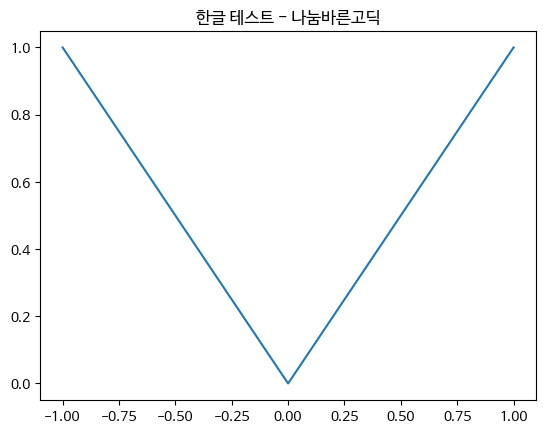

In [4]:
# 폰트 설치 확인

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 1. 설치된 폰트 중 'Nanum'이 들어간 폰트 이름 확인 (선택 사항)
# [f.name for f in fm.fontManager.ttflist if 'Nanum' in f.name]

# 2. 폰트 설정
plt.rcParams["font.family"] = "NanumBarunGothic"
plt.rcParams["axes.unicode_minus"] = False # 마이너스 기호 깨짐 방지

# 3. 테스트
plt.title("한글 테스트 - 나눔바른고딕")
plt.plot([-1, 0, 1], [1, 0, 1])
plt.show()

# 2. 데이터 전처리

## 데이터 준비하기

### 라이브러리 import

In [3]:
import os
import re
import urllib.request
import zipfile
import sentencepiece as spm
import pandas as pd
import matplotlib

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn.utils.rnn import pad_sequence
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset

from tqdm import tqdm
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

print(pd.__version__)
print(torch.__version__)
print(matplotlib.__version__)

cuda
3.0.1
2.5.1
3.10.8


## 데이터 다운로드
아래 링크에서 korean-english-park.train.tar.gz 를 다운로드받아 한영 병렬 데이터를 확보합니다.

- [jungyeul/korean-parallel-corpora](https://github.com/jungyeul/korean-parallel-corpora/tree/master/korean-english-news-v1)

In [4]:
import requests
import tarfile

save_dir = os.path.expanduser("work/s2s_translation/datasets")
filename = "korean-english-park.train.tar.gz"
url = "https://raw.githubusercontent.com/jungyeul/korean-parallel-corpora/master/korean-english-news-v1/korean-english-park.train.tar.gz"

# 전체 파일 경로 만들기 (운영체제에 맞게 경로 결합)
file_path = os.path.join(save_dir, filename)

# 파일일 없으면 파일 다운로드
if not os.path.exists(file_path):

    # 디렉토리(폴더)가 없으면 생성
    # exist_ok=True: 폴더가 이미 있어도 에러를 내지 않음
    os.makedirs(save_dir, exist_ok=True)

    print(f"'{save_dir}' 경로에 다운로드를 시작합니다...")

    # 다운로드 실행
    response = requests.get(url, stream=True)

    if response.status_code == 200:
        with open(file_path, 'wb') as f:
            for chunk in response.iter_content(chunk_size=1024):
                f.write(chunk)
        print(f"다운로드 완료! 저장 위치: {file_path}")
    else:
        print(f"다운로드 실패. 상태 코드: {response.status_code}")


data_folder = os.path.join(save_dir, "kor-eng")
en_path_to_file = os.path.join(data_folder, "korean-english-park.train.en")
ko_path_to_file = os.path.join(data_folder, "korean-english-park.train.ko")

if not os.path.exists(en_path_to_file):
    try:
        print("압축 해제 중...")

        with tarfile.open(file_path, "r:gz") as tar:  # 'r:gz' 모드는 gzip으로 압축된 tar 파일을 읽겠다는 의미입니다.
            tar.extractall(path=data_folder)

        print("압축 해제 완료!")

    except Exception as e:
        print(f"오류 발생: {e}")

print("생성된 파일: ", os.listdir(data_folder))

생성된 파일:  ['korean-english-park.train.en', 'korean-english-park.train.ko']


In [5]:
# 줄바꿈 기준으로 5줄 출력 함수

def print_5line(contents):
    lines = contents.splitlines() # 줄바꿈을 기준으로 나누어 리스트 생성
    for line in lines[:5]:  # 처음 5개 요소(5줄)를 출력
        print(line)

In [6]:
with open(ko_path_to_file, 'r', encoding='utf-8') as file:
    ko_contents = file.read()  # 파일 내용 읽기
    print_5line(ko_contents)   # 확인용 5줄 출력

개인용 컴퓨터 사용의 상당 부분은 "이것보다 뛰어날 수 있느냐?"
모든 광마우스와 마찬가지 로 이 광마우스도 책상 위에 놓는 마우스 패드를 필요로 하지 않는다.
그러나 이것은 또한 책상도 필요로 하지 않는다.
79.95달러하는 이 최첨단 무선 광마우스는 허공에서 팔목, 팔, 그외에 어떤 부분이든 그 움직임에따라 커서의 움직임을 조절하는 회전 운동 센서를 사용하고 있다.
정보 관리들은 동남 아시아에서의 선박들에 대한 많은 (테러) 계획들이 실패로 돌아갔음을 밝혔으며, 세계 해상 교역량의 거의 3분의 1을 운송하는 좁은 해로인 말라카 해협이 테러 공격을 당하기 쉽다고 경고하고 있다.


In [7]:
with open(en_path_to_file, 'r', encoding='utf-8') as file:
    en_contents = file.read()  # 파일 내용 읽기
    print_5line(en_contents)   # 확인용 5줄 출력

Much of personal computing is about "can you top this?"
so a mention a few weeks ago about a rechargeable wireless optical mouse brought in another rechargeable, wireless mouse.
Like all optical mice, But it also doesn't need a desk.
uses gyroscopic sensors to control the cursor movement as you move your wrist, arm, whatever through the air.
Intelligence officials have revealed a spate of foiled plots on ships in Southeast Asia and are warning that a narrow stretch of water carrying almost one third of the world's maritime trade is vulnerable to a terror attack.


## 데이터 전처리: 정제하기

In [8]:
kor_list = ko_contents.split("\n")
eng_list = en_contents.split("\n")

In [9]:
# (kor, eng) 쌍을 튜플로 묶어서 set으로 중복 제거
# cleaned_corpus = list(set(zip(kor_list, eng_list)))  # set 처리후 kor, eng 쌍 이상함
cleaned_corpus = list(zip(kor_list, eng_list))


In [10]:
# 결과 확인
print(f"중복 제거 전: {len(kor_list)}개")
print(f"중복 제거 후: {len(cleaned_corpus)}개")

중복 제거 전: 94124개
중복 제거 후: 94124개


In [11]:
# 데이터프레임 생성 후 상위 5개 출력
df_sample = pd.DataFrame(cleaned_corpus, columns=['Korean', 'English'])
df_sample.head()

,Korean,English
0,"개인용 컴퓨터 사용의 상당 부분은 ""이것보다 뛰어날 수 있느냐?""","Much of personal computing is about ""can you t..."
1,모든 광마우스와 마찬가지 로 이 광마우스도 책상 위에 놓는 마우스 패드를 필요로 하...,so a mention a few weeks ago about a rechargea...
2,그러나 이것은 또한 책상도 필요로 하지 않는다.,"Like all optical mice, But it also doesn't nee..."
3,"79.95달러하는 이 최첨단 무선 광마우스는 허공에서 팔목, 팔, 그외에 어떤 부분...",uses gyroscopic sensors to control the cursor ...
4,정보 관리들은 동남 아시아에서의 선박들에 대한 많은 (테러) 계획들이 실패로 돌아갔...,Intelligence officials have revealed a spate o...


In [12]:
df_sample['Korean'][94122]

'경찰은 김회장의 집무실에서 추가 증거를 찾은 이후 가능한 한 오늘 김회장과 아들을 구속수사 할 방침이다.'

In [13]:
df_sample['English'][94122]

'Police are planning to seek arrest warrants for Kim and his son as early as today, after searching the premises and securing additional material evidence.'

In [14]:
df_sample.shape

(94124, 2)

In [15]:
def preprocess_sentence(sentence):
    sentence = sentence.lower().strip()

    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    sentence = re.sub(r'[" "]+', " ", sentence)
    sentence = re.sub(r"[^가-힣a-zA-Z0-9?.!,]+", " ", sentence)  # 한글, 숫자 추가

    sentence = sentence.strip()

    return sentence

print("슝~")

슝~


In [16]:
# 상위 3만 개만 사용 -> 6만개

df = df_sample[:60000]
# df = df_sample.copy()

df["Korean"] = df["Korean"].apply(preprocess_sentence)
df["English"] = df["English"].apply(lambda x: preprocess_sentence(x))

df.head()

,Korean,English
0,개인용 컴퓨터 사용의 상당 부분은 이것보다 뛰어날 수 있느냐 ?,much of personal computing is about can you to...
1,모든 광마우스와 마찬가지 로 이 광마우스도 책상 위에 놓는 마우스 패드를 필요로 하...,so a mention a few weeks ago about a rechargea...
2,그러나 이것은 또한 책상도 필요로 하지 않는다 .,"like all optical mice , but it also doesn t ne..."
3,"79 . 95달러하는 이 최첨단 무선 광마우스는 허공에서 팔목 , 팔 , 그외에 어...",uses gyroscopic sensors to control the cursor ...
4,정보 관리들은 동남 아시아에서의 선박들에 대한 많은 테러 계획들이 실패로 돌아갔음을...,intelligence officials have revealed a spate o...


### 한글 - KoNLPy의 Mecab 클래스를 사용  ->  Okt로 변경

In [17]:

# install option 1  # 계속 에러
# !pip install konlpy  <- 외부에서 실행

# installl 2  # 계속 에러
# !git clone https://github.com/SOMJANG/Mecab-ko-for-Google-Colab.git
# %cd Mecab-ko-for-Google-Colab
# !bash install_mecab-ko_on_colab_light_220429.sh

# install option 3 # 계속 에러
# !apt-get update
# !apt-get install g++ openjdk-8-jdk
# !pip install konlpy JPype1-py3
# !bash <(curl -s https://raw.githubusercontent.com/konlpy/konlpy/master/scripts/mecab.sh)

In [18]:
# 기존 apt-get 설치 대신 konlpy 공식 스크립트를 사용하여 MeCab 설치
# 아래는 Colab 환경시 실행
# !bash <(curl -s https://raw.githubusercontent.com/konlpy/konlpy/master/scripts/mecab.sh)

# mecab-python은 konlpy.tag.Mecab과는 별개이므로 제거하거나 필요한 경우만 유지
# !pip install mecab-python

# fonts-nanum-coding은 MeCab과는 직접적인 관련이 없지만, 필요한 경우 유지할 수 있습니다。
# !sudo apt-get install -y fonts-nanum-coding # 이미 fonts-nanum은 설치되어 있습니다.

# from konlpy.tag import Mecab

# try:
#     # MeCab 초기화 시 사전 경로를 명시적으로 지정
#     # mecab = Mecab(dicpath="/usr/local/lib/mecab/dic/mecab-ko-dic")  # Colab 환경시 실행
#     mecab = Mecab()  
#     test_sentence = mecab.morphs("아버지가 방에 들어갑니다.")
#     print("✅ Mecab 정상 동작:", test_sentence)
    
# except Exception as e:
#     print(f"Mecab 초기화 실패: {e}")
#     print("MeCab 설치가 올바른지 확인하거나 런타임을 다시 시작해 보세요.")

from konlpy.tag import Okt

okt = Okt()
test_sentence = okt.morphs("아버지가 방에 들어갑니다.")
print("✅ Okt 정상 동작:", test_sentence)
    

✅ Okt 정상 동작: ['아버지', '가', '방', '에', '들어갑니다', '.']


## 데이터 전처리: 토큰화

In [21]:
# 토큰 길이 40 -> 60 이하인 데이터만 선별 (모든 데이터를 사용할 경우 학습에 굉장히 오랜 시간이 걸립니다.)
mask = (
    df["Korean"].str.split(" ").str.len() <= 60   # <= 40  # 한국어 토큰 길이
) & (
    df["English"].str.split(" ").str.len() <= 60  # <= 40  # 영어 토큰 길이
)

# 필터링된 데이터프레임
filtered_df = df[mask].copy()

# # Mecab 객체 생성  # Mecab error ------------------------------------ Opt 1
# mecab = Mecab()

# # filtered_df["Korean"]에 한글 문장 리스트가 있다고 가정
# with open('korean_mecab.txt', 'w', encoding='utf-8') as f:
#     for kor_sentence in filtered_df["Korean"]:

#         # Mecab으로 형태소 분리 (예: "아버지가 방에" -> ['아버지', '가', '방', '에'])
#         morphs = mecab.morphs(kor_sentence)

#         # 공백으로 합쳐서 한 줄에 저장 (예: "아버지 가 방 에")
#         # SentencePiece는 텍스트 파일을 입력으로 받기 때문
#         f.write(' '.join(morphs) + '\n')

# print("Mecab 전처리 완료! 'korean_mecab.txt' 생성됨.")
# print(f"총 {len(filtered_df)} 문장 처리됨.")

# filtered_df["English"].to_csv("p2_eng_corpus.txt", index=False, header=False, sep="\n", encoding="utf-8")

# print("파일 저장 완료: p2_eng_corpus.txt, korean_mecab.txt")
# Mecab_Okt_option = 1



# Okt 로 진행 -----------------------------------------------------------Opt 2
# 1. Okt 객체 초기화
# 1. Okt 객체 초기화
okt = Okt()

# 2. 전처리 및 파일 저장
with open('korean_okt.txt', 'w', encoding='utf-8') as f:
    for kor_sentence in filtered_df["Korean"]:
        
        # Okt로 형태소 분석 (예: "아버지가" -> ['아버지', '가'])
        # stem=True 옵션을 주면 '가고있다' -> '가다'처럼 원형 복원이 가능합니다 (선택사항)
        morphs = okt.morphs(kor_sentence)
        
        # 형태소들을 공백으로 구분된 문자열로 변환하여 파일에 쓰기
        f.write(' '.join(morphs) + '\n')

print("Okt 전처리 완료! 'korean_okt.txt' 생성됨.")
print(f"총 {len(filtered_df)} 문장 처리됨.")

filtered_df["English"].to_csv("p2_eng_corpus.txt", index=False, header=False, sep="\n", encoding="utf-8")

print("파일 저장 완료: p2_eng_corpus.txt, korean_okt.txt")

Mecab_Okt_option = 2


# 그냥 진행 ----------------------------------------------------Opt 3
# filtered_df["Korean"].to_csv("p2_kor_corpus.txt", index=False, header=False, sep="\n", encoding="utf-8")
# filtered_df["English"].to_csv("p2_eng_corpus.txt", index=False, header=False, sep="\n", encoding="utf-8")

# print("파일 저장 완료: p2_eng_corpus.txt, p2_kor_corpus.txt")

# Mecab_Okt_option = 3


Okt 전처리 완료! 'korean_okt.txt' 생성됨.
총 59765 문장 처리됨.
파일 저장 완료: p2_eng_corpus.txt, korean_okt.txt


### SentencePiece를 활용해 Tokenizer를 생성하고 테이터를 변환

#### 1. SentencePiece 주요 역할 (핵심 기능)
- 인코딩 (Encoding): 문장을 토큰(Token) 단위로 쪼개고, 각 토큰을 고유한 숫자(Index)로 변환합니다.
    - 예: "아버지가 방에" → ['아버지', '가', '방', '에'] → [105, 22, 403, 9]
- 디코딩 (Decoding): 모델이 내놓은 숫자 리스트를 다시 원래의 문장으로 합칩니다.
    - 예: [105, 22, 403, 9] → "아버지가 방에"
- 어휘 사전 관리 (Vocabulary Management): 학습 데이터를 통해 가장 자주 쓰이는 단어/서브워드 조각들을 모아 vocab 파일을 만들고 관리합니다.

#### 2. SentencePiece 토크나이저만의 차별점
SentencePiece는 일반적인 형태소 분석기(Mecab, Okt 등) 기반 토크나이저와 작동 방식이 조금 다릅니다.

① 공백도 문자로 취급 (언더바 _ 활용)
기존 방식은 공백을 기준으로 단어를 나누고 공백을 버리지만, SentencePiece는 공백을 _(U+2581)라는 특수 문자로 치환하여 보존합니다. 덕분에 디코딩할 때 원래 문장의 띄어쓰기를 완벽하게 복원할 수 있습니다.

② 서브워드(Subword) 분리 (BPE/Unigram)
단어를 더 작은 단위로 쪼개어 '미등록 단어(OOV, Out-Of-Vocabulary)' 문제를 해결합니다.

예를 들어 "신조어"라는 단어가 사전에 없어도, "신", "조", "어"라는 글자 조각들이 사전에 있다면 이를 조합해서 인식합니다.

③ 언어 독립성 (Language Independent)
Mecab처럼 특정 언어(한국어)의 문법 규칙을 미리 알 필요가 없습니다. 단순히 데이터의 통계적 빈도를 기반으로 쪼개기 때문에 한국어, 영어, 일본어 심지어 이모지까지 동일한 로직으로 처리합니다.

#### 3. 작업 흐름도
SentencePiece 작업은 크게 **학습(Train)**과 추론(Inference) 단계로 나뉩니다.
- Train: 텍스트 뭉치(Corpus)를 읽어 빈도수가 높은 조각들을 모아 .model과 .vocab 파일을 만듭니다.
- Inference (Tokenizer 역할): 생성된 .model 파일을 불러와 실시간으로 문장을 쪼개고 숫자로 바꿉니다.

#### 4. Mecab이나 Okt로 미리 형태소를 나눈 뒤 SentencePiece를 돌리는 이유
**"한국어의 특성을 미리 반영해 주어 SentencePiece가 더 효율적인 조각을 찾도록 돕기 위해서"**입니다. (이를 Pre-tokenization이라고 합니다.)

In [25]:
vocab_size = 20000  # 9914 # 오류 메시지에 따라 vocab_size를 9914 이하로 수정 (korean_mecab.txt 코퍼스에서는 최대 9914개의 고유한 단어만 추출)
pad_id = 0
bos_id = 1
eos_id = 2
unk_id = 3

if Mecab_Okt_option == 1:  # MeCab 사용 시
    input_file = "korean_mecab.txt"
    model_prefix = "p3_encoder_spm"

elif Mecab_Okt_option == 2:  # Okt 사용 시
    input_file = "korean_okt.txt"
    model_prefix = "p4_encoder_spm"

else:  # 그 외
    input_file = "p2_kor_corpus.txt"
    model_prefix = "p2_encoder_spm"


spm.SentencePieceTrainer.train(
    input = input_file,        
    model_prefix = model_prefix, 
    vocab_size = vocab_size,
    pad_id = pad_id,
    bos_id = bos_id,
    eos_id = eos_id,
    unk_id = unk_id
)

spm.SentencePieceTrainer.train(
    input = "p2_eng_corpus.txt",
    model_prefix = "p2_decoder_spm",
    vocab_size = vocab_size,
    pad_id = pad_id,
    bos_id = bos_id,
    eos_id = eos_id,
    unk_id = unk_id
)

In [26]:
model_name = model_prefix + ".model"
encoder_tokenizer = spm.SentencePieceProcessor()
encoder_tokenizer.load(model_name)

decoder_tokenizer = spm.SentencePieceProcessor()
decoder_tokenizer.load("p2_decoder_spm.model")

True

### 데이타 확인

In [27]:
df

,Korean,English
0,개인용 컴퓨터 사용의 상당 부분은 이것보다 뛰어날 수 있느냐 ?,much of personal computing is about can you to...
1,모든 광마우스와 마찬가지 로 이 광마우스도 책상 위에 놓는 마우스 패드를 필요로 하...,so a mention a few weeks ago about a rechargea...
2,그러나 이것은 또한 책상도 필요로 하지 않는다 .,"like all optical mice , but it also doesn t ne..."
3,"79 . 95달러하는 이 최첨단 무선 광마우스는 허공에서 팔목 , 팔 , 그외에 어...",uses gyroscopic sensors to control the cursor ...
4,정보 관리들은 동남 아시아에서의 선박들에 대한 많은 테러 계획들이 실패로 돌아갔음을...,intelligence officials have revealed a spate o...
...,...,...
59995,발굴팀은 발견된 석회암 외벽으로 한 때 완벽한 피라미드의 높이가 14m였을 것으로 ...,which enabled them to calculate that the compl...
59996,발굴된 피라미드는 지금 까지 이집트에서 발굴된 118번째 피라미드다 .,the pyramid is the 118th discovered so far in ...
59997,하와즈 위원장은 새로운 피라미드의 발견은 항상 흥미롭다 며 이 피라미드는 신기하게도...,"to find a new pyramid is always exciting , sai..."
59998,하와즈 위원장은 이 피라미드가 제6왕조를 세우고 원한 관계였던 왕실의 두 분파를 연...,it belonged to a queen . hawass said he believ...


In [28]:
eng_sample = df["English"][1000]
kor_sample = df["Korean"][1000]
print(eng_sample)
print('-' * 10)
print(kor_sample)

but these days that rationale is being questioned .
----------
그러나 요즈음에 그러한 이론적 해석이 의문시되고 있다 .


In [29]:
enc_token = encoder_tokenizer.encode(eng_sample)
enc_token = [encoder_tokenizer.bos_id()] + enc_token + [encoder_tokenizer.eos_id()]
enc_token

[1,
 14850,
 798,
 7663,
 6202,
 506,
 10729,
 4,
 17737,
 1270,
 1081,
 6590,
 3933,
 2090,
 4,
 9700,
 506,
 2952,
 2971,
 5,
 2]

In [30]:
enc_decoding = encoder_tokenizer.decode(enc_token)
enc_decoding

'but these days that rationale is being questioned .'

In [31]:
pieces = encoder_tokenizer.encode_as_pieces(eng_sample)
print(pieces)

['▁but', '▁the', 'se', '▁day', 's', '▁that', '▁', 'ration', 'a', 'le', '▁is', '▁be', 'ing', '▁', 'que', 's', 'tion', 'ed', '▁.']


In [32]:
kor_token = encoder_tokenizer.encode(kor_sample)
kor_token = [encoder_tokenizer.bos_id()] + kor_token + [encoder_tokenizer.eos_id()]
kor_token

[1,
 138,
 642,
 316,
 279,
 193,
 2062,
 38,
 3487,
 306,
 63,
 593,
 72,
 2299,
 69,
 8896,
 37,
 5,
 2]

In [33]:
pieces = encoder_tokenizer.encode_as_pieces(kor_sample)
print(pieces)

['▁그러나', '▁요', '즈', '음', '에', '▁그러', '한', '▁이론', '적', '▁해', '석', '이', '▁의문', '시', '되고', '▁있다', '▁.']


In [34]:
kor_decoding = encoder_tokenizer.decode(kor_token)
kor_decoding

'그러나 요즈음에 그러한 이론적 해석이 의문시되고 있다 .'

### 데이터셋 생성
START_TOKEN, END_TOKEN 추가 + Padding

In [35]:
class TranslationDataset(Dataset):
    def __init__(self, data, encoder_tokenizer, decoder_tokenizer, max_len):
        self.data = data
        self.encoder_tokenizer = encoder_tokenizer
        self.decoder_tokenizer = decoder_tokenizer
        self.max_len = max_len
        self.pad_id = 0
        self.bos_id = 1
        self.eos_id = 2

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        src_text = self.data.iloc[idx]['Korean']
        trg_text = self.data.iloc[idx]['English']

        src_ids = self.encoder_tokenizer.encode(src_text)
        trg_ids = self.decoder_tokenizer.encode(trg_text)

        src_ids = src_ids[:self.max_len]

        # Decoder의 입력에는 START_TOKEN과 END_TOKEN을 추가해줍니다. 단, 최대 길이 제한을 적용시킵니다.
        trg_input = [self.bos_id] + trg_ids[:self.max_len - 2] + [self.eos_id]
        trg_label = trg_ids[:self.max_len - 1] + [self.eos_id]

        # 길이가 짧은 경우 PAD_TOKEN을 추가해줍니다.
        src_ids = src_ids + [self.pad_id] * (self.max_len - len(src_ids))
        trg_input = trg_input + [self.pad_id] * (self.max_len - len(trg_input))
        trg_label = trg_label + [self.pad_id] * (self.max_len - len(trg_label))

        return torch.tensor(src_ids), torch.tensor(trg_input), torch.tensor(trg_label)

### train data 준비 (난이도에 비해 데이터가 많지 않아 훈련 데이터와 검증 데이터를 따로 나누지는 않습니다.)

In [36]:
MAX_LEN = 80  # 40 # 임의의 값
BATCH_SIZE = 64

train_data = df.copy()

train_data.reset_index(drop=True, inplace=True)

train_data = TranslationDataset(train_data, encoder_tokenizer, decoder_tokenizer, max_len=MAX_LEN)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
validation_loader = None  # 또는 []

In [37]:
for src, trg_input, trg_label in train_loader:
    print(src.shape, trg_input.shape, trg_label.shape)
    break

torch.Size([64, 80]) torch.Size([64, 80]) torch.Size([64, 80])


## 3. 모델 설계
### Bahdanau Attention 설계

In [38]:
class BahdanauAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()

        self.W1 = nn.Linear(hidden_dim, hidden_dim)
        self.W2 = nn.Linear(hidden_dim, hidden_dim)
        self.v = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs):
        # hidden: (1, batch_size, hidden_dim) 또는 (batch_size, hidden_dim)으로 올 수 있음
        # LSTM hidden state는 (num_layers, batch_size, hidden_dim) 형태이므로, 첫 번째 차원(레이어)을 제거합니다.
        if hidden.dim() == 3:
            hidden = hidden.squeeze(0) # (batch_size, hidden_dim)

        # encoder_outputs: (batch_size, src_len, hidden_dim) (Encoder에서 batch_first=True로 오기 때문에)

        # src_len을 encoder_outputs의 두 번째 차원(원본 src_len)에서 가져옵니다.
        src_len = encoder_outputs.shape[1] # <--- 수정: shape[0] 대신 shape[1]

        # hidden을 (batch_size, src_len, hidden_dim) 형태로 확장합니다.
        hidden_for_attention = hidden.unsqueeze(1).repeat(1, src_len, 1) # (batch_size, src_len, hidden_dim)

        # encoder_outputs는 이미 (batch_size, src_len, hidden_dim) 형태이므로 permute가 필요 없습니다.
        # 기존: encoder_outputs = encoder_outputs.permute(1, 0, 2) # 이 줄을 제거합니다.

        energy = torch.tanh(self.W1(encoder_outputs) + self.W2(hidden_for_attention))  # (batch_size, src_len, hidden_dim)
        attention = self.v(energy).squeeze(2)  # (batch_size, src_len)

        return nn.functional.softmax(attention, dim=1)  # (batch_size, src_len)

### Encoder, Decoder 설계

In [39]:
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hidden_dim, num_layers):
        super().__init__()

        self.embedding = nn.Embedding(input_dim, emb_dim)
        # batch_first=False로 변경 (또는 embedded.permute(1, 0, 2)를 forward에서 추가)
        self.rnn = nn.LSTM(emb_dim, hidden_dim, num_layers, batch_first=True)  # =False)

    def forward(self, src):
        # src : (src_len, batch_size)
        embedded = self.embedding(src)  # embedded : (src_len, batch_size, emb_dim)

        # 만약 batch_first=True를 유지하고 싶다면 아래 라인의 주석을 해제
        embedded = embedded.permute(1, 0, 2) # (batch_size, src_len, emb_dim)

        outputs, (h_0, c_0) = self.rnn(embedded)  # outputs : (src_len, batch_size, hidden_dim) (batch_first=False일 경우)
                                                  # 또는 (batch_size, src_len, hidden_dim) (batch_first=True이고 embedded를 permute한 경우)
        # h_0, c_0 : (1, batch_size, hidden_dim)  # num_layers * num_directions, batch, hidden_dim

        return outputs, h_0, c_0

In [40]:
class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim, attention, num_layers):
        super(Decoder, self).__init__()

        self.output_dim = output_dim
        self.attention = attention
        self.embedding = nn.Embedding(output_dim, emb_dim)
        # Decoder RNN에는 embedding과 context vector가 결합되어 입력
        self.rnn =  nn.LSTM(emb_dim + hidden_dim, hidden_dim, num_layers, batch_first=True)
        # 출력층에는 hidden state와 attention value가 결합되어 입력
        self.fc_out = nn.Linear(hidden_dim + hidden_dim, output_dim)

    def forward(self, input, hidden, cell, encoder_outputs):
        # input : (batch_size,)
        # hidden : (batch_size, hidden_dim)
        # encoder_outputs : (batch_size, src_len, hidden_dim)
        input = input.unsqueeze(0)  # input : (1, batch_size)
        embedded = self.embedding(input)  # embedded : (1, batch_size, emb_dim)

        # attention distribution을 계산합니다.
        a = self.attention(hidden[-1], encoder_outputs)  # a : (batch_size, src_len)

        # H에 가중치를 부여해 attention value(Context vector) 계산
        a = a.unsqueeze(1)  # a : (batch_size, 1, src_len)
        # encoder_outputs는 이미 (batch_size, src_len, hidden_dim) 형태이므로 permute가 필요 없습니다. 이 줄을 제거합니다.
        # encoder_outputs = encoder_outputs.permute(1, 0, 2)
        context = torch.bmm(a, encoder_outputs)  # context : (batch_size, 1, hidden_dim), bmm: Batch Matrix Multiplication
        context = context.permute(1, 0, 2)  # context : (1, batch_size, hidden_dim)

        # embedded와 context를 결합하여 RNN에 전달
        rnn_input = torch.cat((embedded, context), dim=2) # (1, batch_size, emb_dim + hidden_dim)
        # rnn_input을 (batch_size, 1, emb_dim + hidden_dim) 형태로 permute합니다. (batch_first=True를 위해)
        rnn_input = rnn_input.permute(1, 0, 2)

        output, (hidden, cell) = self.rnn(rnn_input, (hidden, cell))

        # 출력층에서는 현재 hidden state와 context vector를 결합하여 예측값 생성
        output = output.squeeze(1)  # output : (batch_size, hidden_dim)  <-- 여기를 squeeze(1)로 변경합니다.
        context = context.squeeze(0)  # context : (batch_size, hidden_dim)
        prediction = self.fc_out(torch.cat((output, context), dim=1))  # (batch_size, output_dim)

        return prediction, hidden, cell, a.squeeze(1)

### Seq2SeqAttention model 설계

In [41]:
class Seq2SeqAttention(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg=None, max_len=30, bos_id = 1, eos_id=2):
        # 학습 모드에서는 trg_len 사용, 추론 모드에서는 max_len까지 동적 생성
        batch_size = src.shape[1] # src가 (src_len, batch_size) 형태라고 가정
        trg_vocab_size = self.decoder.fc_out.out_features

        # 조기 종료를 위해 tensor가 아닌 리스트 사용
        outputs = []

        # 시각화를 위해 attention 저장
        attentions = []

        # 인코더를 통해 context 생성
        encoder_outputs, hidden, cell = self.encoder(src) # h_0와 c_0를 hidden, cell로 받음

        if trg is not None:
            for t in range(0, trg.shape[0]):
                input = trg[t]
                output, hidden, cell, attention = self.decoder(input, hidden, cell, encoder_outputs) # hidden과 cell을 모두 전달
                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))

        else:
		    # inference에서는 target(정답)이 없기 때문에 sos_token을 생성해줍니다.
            input = torch.full((batch_size,), bos_id, dtype=torch.long, device=self.device)
            finished = torch.zeros(batch_size, dtype=torch.bool, device=self.device)

            for t in range(max_len):
                output, hidden, cell, attention = self.decoder(input, hidden, cell, encoder_outputs) # hidden과 cell을 모두 전달
                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))
                top1 = output.argmax(1)
                input = top1

                # 조기 종료 조건
                finished |= (top1 == eos_id)
                if finished.all():
                    break

        outputs = torch.cat(outputs, dim=0)  # (trg_len, batch_size, output_dim)
        attentions = torch.cat(attentions, dim=0)  # (trg_len, batch_size, src_len)

        return outputs, attentions

In [49]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

input_dim = len(encoder_tokenizer)
output_dim = len(decoder_tokenizer)
emb_dim = 256   # 256
hid_dim = 512  # 512
NUM_LAYERS = 3  # LSTM Layers = 3

In [50]:
encoder = Encoder(input_dim, emb_dim, hid_dim, NUM_LAYERS).to(device)
attention = BahdanauAttention(hid_dim).to(device)
decoder = Decoder(output_dim, emb_dim, hid_dim, attention, NUM_LAYERS).to(device)
model = Seq2SeqAttention(encoder, decoder, device).to(device)

In [51]:
print(model)

Seq2SeqAttention(
  (encoder): Encoder(
    (embedding): Embedding(20000, 256)
    (rnn): LSTM(256, 512, num_layers=3, batch_first=True)
  )
  (decoder): Decoder(
    (attention): BahdanauAttention(
      (W1): Linear(in_features=512, out_features=512, bias=True)
      (W2): Linear(in_features=512, out_features=512, bias=True)
      (v): Linear(in_features=512, out_features=1, bias=False)
    )
    (embedding): Embedding(20000, 256)
    (rnn): LSTM(768, 512, num_layers=3, batch_first=True)
    (fc_out): Linear(in_features=1024, out_features=20000, bias=True)
  )
)


## 4. 훈련하기
### (1) Optimizer & Loss

In [52]:
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(ignore_index=pad_id)

print("슝~")

슝~


### (2) train_step 구현하기

In [53]:
def train_step(model, data_loader, optimizer, criterion, epoch):
    model.train()
    epoch_loss = 0

    progress_bar = tqdm(data_loader, desc=f"Epoch {epoch+1}", leave=True)

    for src, trg_input, trg_label in progress_bar:
        # 모델의 입력 순서에 맞게 transpose 변환
        src = src.permute(1, 0).to(device)
        trg_input = trg_input.permute(1, 0).to(device)
        trg_label = trg_label.permute(1, 0).to(device)
        optimizer.zero_grad()

        outputs,_ = model(src, trg_input)

        # (trg_len, batch_size, output_dim)을 (batch_size * trg_len, output_dim)으로 변환
        outputs = outputs.reshape(-1, outputs.shape[-1])
        trg_label = trg_label.reshape(-1)

        loss = criterion(outputs, trg_label)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1)

        optimizer.step()

        epoch_loss += loss.item()

        progress_bar.set_postfix(loss=loss.item())

    return epoch_loss / len(data_loader)

print("슝~")


슝~


### (3) 훈련 시작하기

In [54]:
def eval_step(model, data_loader, optimizer, criterion):
    model.eval()
    total_loss = 0

    for src, trg_input, trg_label in data_loader:
        # 모델의 입력 순서에 맞게 transpose 변환
        src = src.permute(1, 0).to(device)
        trg_input = trg_input.permute(1, 0).to(device)
        trg_label = trg_label.permute(1, 0).to(device)

        outputs,_ = model(src, trg_input)

        # (trg_len, batch_size, output_dim)을 (batch_size * trg_len, output_dim)으로 변환
        outputs = outputs.reshape(-1, outputs.shape[-1])
        trg_label = trg_label.reshape(-1)

        loss = criterion(outputs, trg_label)

        total_loss += loss.item()

    return total_loss / len(data_loader)

print("슝~")

슝~


In [55]:
%%time

EPOCHS = 10  # 20

for epoch in range(EPOCHS):
    train_loss = train_step(model, train_loader, optimizer, criterion, epoch)
    if validation_loader:
        valid_loss = eval_step(model, validation_loader, optimizer, criterion)
        print(f'Epoch {epoch+1}/{EPOCHS}, Train Loss: {train_loss:.4f}, Validation Loss: {valid_loss:.4f}')
    else:
        print(f'Epoch {epoch+1}/{EPOCHS}, Train Loss: {train_loss:.4f}')

Epoch 1: 100%|████████████████████████████████████████████████████████████| 938/938 [09:32<00:00,  1.64it/s, loss=4.95]


Epoch 1/10, Train Loss: 5.6944


Epoch 2: 100%|████████████████████████████████████████████████████████████| 938/938 [09:40<00:00,  1.62it/s, loss=4.16]


Epoch 2/10, Train Loss: 4.5391


Epoch 3: 100%|████████████████████████████████████████████████████████████| 938/938 [09:39<00:00,  1.62it/s, loss=4.06]


...

Epoch 8/10, Train Loss: 2.3868


Epoch 9: 100%|████████████████████████████████████████████████████████████| 938/938 [09:42<00:00,  1.61it/s, loss=2.29]


Epoch 9/10, Train Loss: 2.1822


Epoch 10: 100%|███████████████████████████████████████████████████████████| 938/938 [09:38<00:00,  1.62it/s, loss=2.07]

Epoch 10/10, Train Loss: 2.0034
CPU times: total: 41min 22s
Wall time: 1h 36min 39s


### 번역 성능 평가 + Attention Map 시각화

In [56]:
def evaluate(sentence, model, encoder_tokenizer, decoder_tokenizer, max_len=30):
    model.eval()

    sentence = preprocess_sentence(sentence)
    src_ids = encoder_tokenizer.encode(sentence)
    src_ids = src_ids[:max_len]
    src_ids = src_ids + [0] * (max_len - len(src_ids))  # 패딩 추가
    src_tensor = torch.tensor(src_ids).unsqueeze(1).to(device)  # (src_len, 1)

    with torch.no_grad():
        outputs, attentions = model(src_tensor, max_len=max_len)

    result = [decoder_tokenizer.decode([token.item()]) for token in outputs.argmax(2).squeeze(1)]

    if "<end>" in result:
        result = result[:result.index("<end>")]

    return result, sentence, attentions.squeeze(1).cpu().numpy()

In [57]:
def plot_attention(attention, sentence, predicted_sentence):
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.matshow(attention, cmap='viridis')

    fontdict = {'fontsize': 14}

    ax.set_xticks(range(len(sentence)))
    ax.set_xticklabels(sentence, fontdict=fontdict, rotation=90)

    ax.set_yticks(range(len(predicted_sentence)))
    ax.set_yticklabels(predicted_sentence, fontdict=fontdict)

    plt.show()

In [58]:
def translate(sentence, model, encoder_tokenizer, decoder_tokenizer, max_len=30):
    result, sentence, attention = evaluate(sentence, model, encoder_tokenizer, decoder_tokenizer, max_len)

    print('Input: %s' % (sentence))
    print('Predicted translation: {}'.format(result))

    # Attention 크기 조정 (trg_len, src_len)
    attention = attention[:len(result), :len(sentence.split())]

    plot_attention(attention, sentence.split(), result)

Input: 오바마는 대통령이다 .
Predicted translation: ['obama', 'will', 'also', 'be', 'the', 'first', 'african', 'president', '.', '']


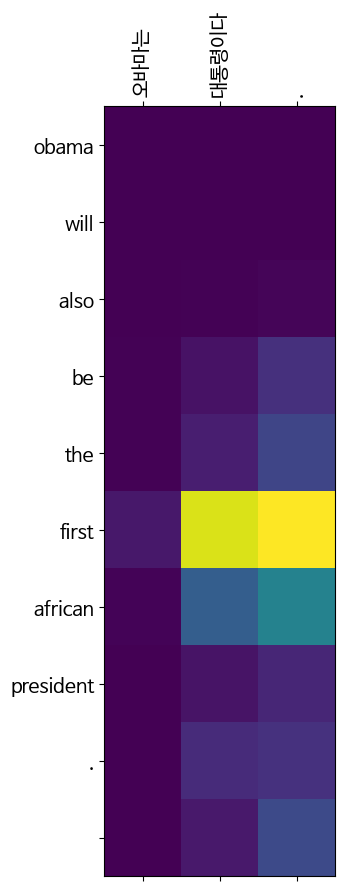

In [59]:
translate("오바마는 대통령이다.", model, encoder_tokenizer, decoder_tokenizer, max_len=30)

Input: 시민들은 도시 속에 산다 .
Predicted translation: ['the', 'city', 'is', 'among', 'the', 'city', '.', '']


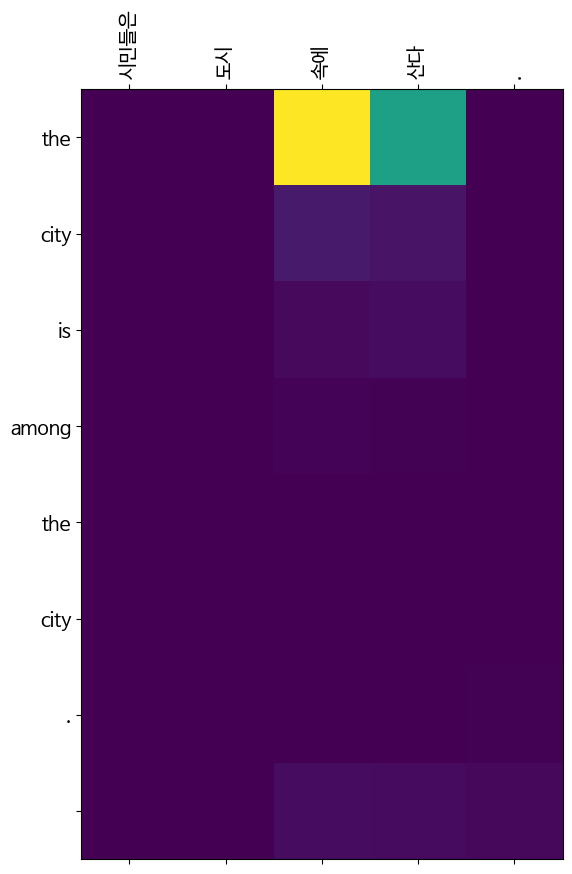

In [60]:
translate("시민들은 도시 속에 산다.", model, encoder_tokenizer, decoder_tokenizer, max_len=30)

Input: 커피는 필요 없다 .
Predicted translation: ['it', 'can', 'be', 'hurt', 'ful', '.', '']


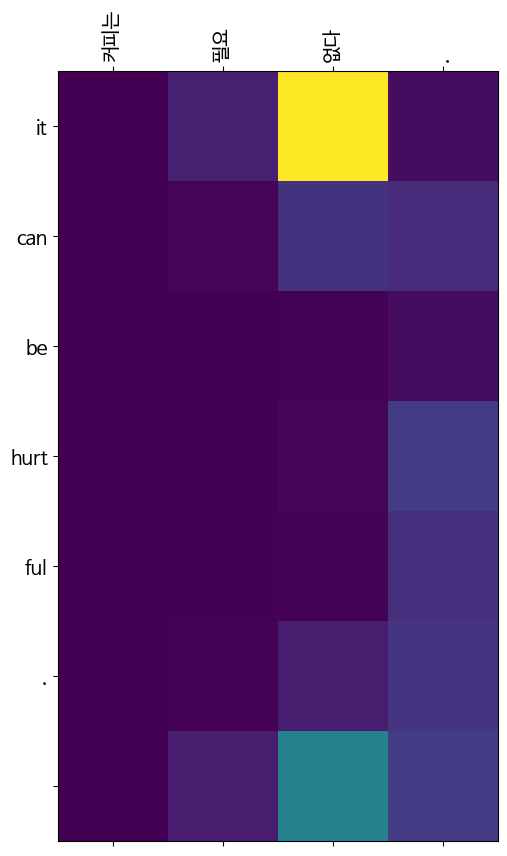

In [61]:
# 실행 예제
translate("커피는 필요 없다.", model, encoder_tokenizer, decoder_tokenizer, max_len=30)

Input: 일곱 명의 사망자가 발생했다 .
Predicted translation: ['a', 'total', 'of', '20', 'people', 'were', 'kill', 'ed', '.', '']


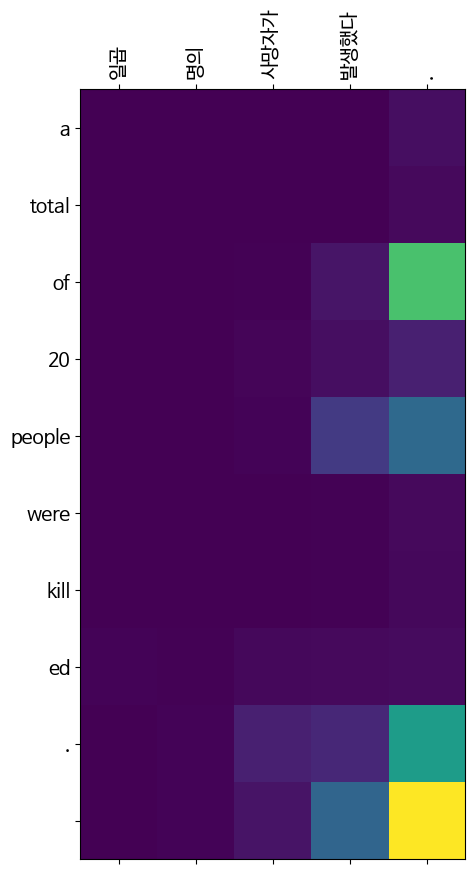

In [62]:
translate("일곱 명의 사망자가 발생했다.", model, encoder_tokenizer, decoder_tokenizer, max_len=30)

# 학습 결과

1. Okt로 미리 형태소를 나눈 뒤 SentencePiece 실행해서 좀더 나은 결과가 나온것 같습니다.
2. 아래 예제가 좀더 나은 결과 입니다.

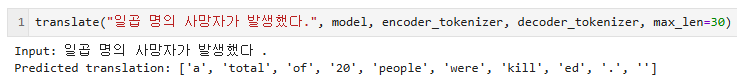